# Commande PID d'un double intégrateur


Le but de ce notebook est de calculer et simuler un correcteur **PID discret** agissant sur un modèle de balle sur poutre (double intégrateur). La synthèse est directe : on choisit les gains Kp, Ki, Kd, et on observe la réponse en boucle fermée ainsi que le rejet de perturbation.

In [1]:
from Models.BallBeam import ballbeam_config
from Models.BallBeam.StateSpace import LinearStateSpaceModel
from Models.BallBeam.TransferFunctions import TransferFunctionModel

from Simulation.simulation import TFSimulator
from Simulation.simulation import HybridSim

from Simulation.runners import *

from Metrics_Plotting.SimLog import SimLog
from Metrics_Plotting.Plotting import Plotting
from Metrics_Plotting.Metrics import Metrics

from Control.DiscretePID import DiscretePID
from Control.RSTController import RSTController

from Utils import computeRST
from Utils import utils

import numpy as np
import control as ct
import matplotlib.pyplot as plt

%matplotlib inline

Configuration de la simulation:


T est le temps total de simulation et dt est le temps d'échantillonage du correcteur

In [2]:
ballbeam_config.T=6
ballbeam_config.dt=0.05

In [3]:
X_0 = np.array([[0],[0]])                              # état initial
double_int = TransferFunctionModel(ballbeam_config)    # instance de TransferFunctionModel
Double_int_sim = TFSimulator(double_int.Tf_dis, X_0)   # simulateur de fonctions de transfert discrètes
A = double_int.Tf_dis.den_list[0][0]                   # extraction du dénominateur A(z)
B = double_int.Tf_dis.num_list[0][0]                   # extraction du numérateur B(z)

In [4]:
### affichage 
print(double_int.Tf_cont)
print(double_int.Tf_dis)

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.21
  ----
  s^2
<TransferFunction>: sys[0]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.0002625 z + 0.0002625
  -----------------------
       z^2 - 2 z + 1


Détermination des gains du PID

In [5]:
kp = 280
ki = 0    # sans action intégrale : erreur statique non nulle face à une perturbation constante
kd = 95

Synthèse du correcteur PID:
Ici, nous ajoutons un filtre de l'action dérivée avec le mot-clé "filtered"

In [6]:
PID_controller=DiscretePID(kp,ki,kd,ballbeam_config.dt,"filtered")

In [7]:
L = PID_controller.transferFunction * double_int.Tf_dis
T_cl = ct.feedback(L, 1)
print(T_cl)
print("DC gain:       ", T_cl.dcgain())
cl_poles = np.roots(T_cl.den_list[0][0])
print("Closed-loop poles (z):", cl_poles)
print("Pole radii:           ", np.abs(cl_poles))

<TransferFunction>: sys[12]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

      1.504 z^2 + 0.1837 z - 1.32
  ------------------------------------
  3.5 z^3 - 6.496 z^2 + 5.684 z - 2.32
DC gain:        0.9999999999999988
Closed-loop poles (z): [0.86458984+0.j         0.49568723+0.72186597j 0.49568723-0.72186597j]
Pole radii:            [0.86458984 0.87566906 0.87566906]


### Marges de stabilité

Les marges de gain et de phase quantifient la robustesse de la boucle fermée.

In [8]:
Performance_Stabilite=Metrics()
Performance_Stabilite.Stability(L)

Gain margin:   3.8 dB  (×1.55)
Phase margin:  15.9°


### Simulation
On utilise le simulateur discret. Le premier True/False détermine la présence d'une perturbation constante au bout de la troisième seconde. Le deuxième active (si True) la saturation de l'actionneur.

In [9]:
logger_PID = SimLog()

reference = 1.0
y_0 = 0.0

logger_PID = run_discrete_control(Double_int_sim, PID_controller, ballbeam_config, reference, y_0, logger_PID, True, True)

### Métriques de performance

Calcul du dépassement, du temps de montée et du temps de réponse (bande ±2 %) sur la phase de suivi de consigne (avant perturbation).

In [ ]:
Performance_Stabilite.response_data(logger_PID,reference,)

Dépassement :          14.3 %
Temps de montée :      0.650 s  (10 %→90 %)
Temps d'établissement :     1.650 s  (bande ±10 %)


Création de la fonction de transfert perturbation/sortie :

$$G_d(z) = \frac{B(z)\,S(z)}{A(z)\,S(z) + B(z)\,R(z)}$$

Un gain DC non nul indique une erreur statique résiduelle (attendue ici car $K_i = 0$).

In [11]:
A_arr = np.squeeze(A)
B_arr = np.squeeze(B)
R_arr = np.squeeze(PID_controller.R.num[0][0])
S_arr = np.squeeze(PID_controller.S.num[0][0])

num_d = np.polymul(B_arr, S_arr)
den_d = np.polyadd(np.polymul(A_arr, S_arr), np.polymul(B_arr, R_arr))

Gd = ct.tf(num_d, den_d, ballbeam_config.dt)
print(Gd)
print("DC gain Gd:", ct.dcgain(Gd))

t = np.arange(0, ballbeam_config.T, ballbeam_config.dt)
t = np.asarray(t).flatten()
_, d_resp = ct.step_response(Gd, t)
d_resp = np.squeeze(d_resp)

<TransferFunction>: sys[13]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.0009187 z^2 + 0.0006563 z - 0.0002625
  ---------------------------------------
   3.5 z^3 - 6.496 z^2 + 5.684 z - 2.32
DC gain Gd: 0.003571428571428567


Affichage des trois réponses

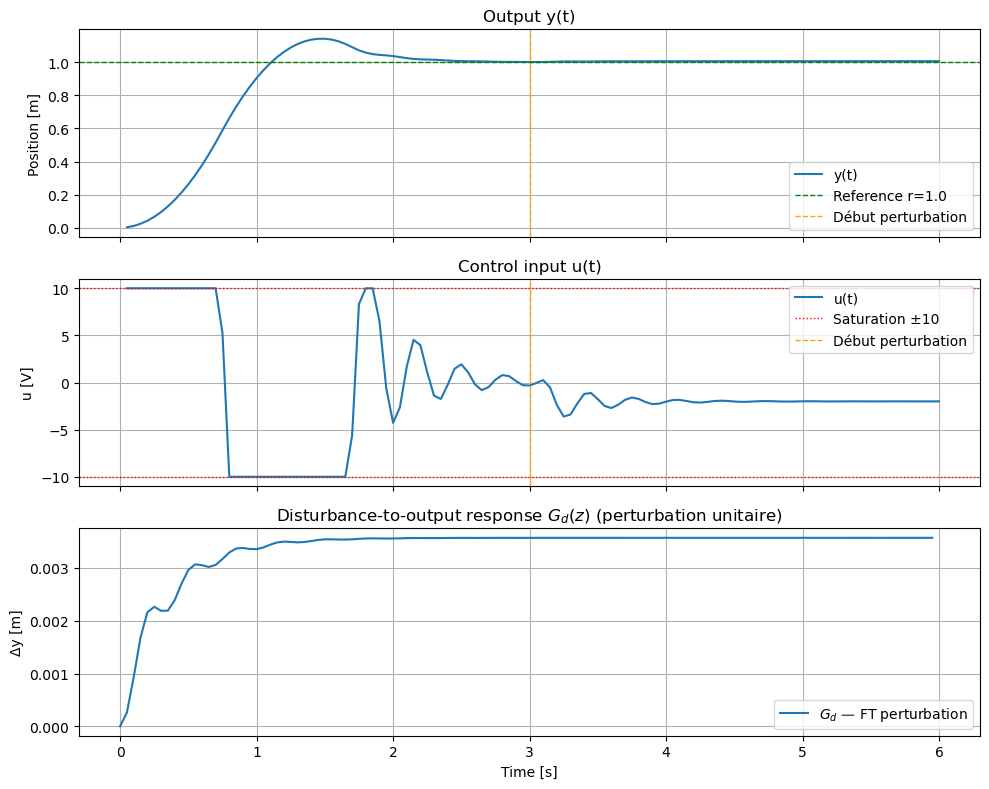

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(logger_PID.t_hist, logger_PID.y_hist, label='y(t)')
ax[0].axhline(y=reference, color='green', linestyle='--', linewidth=1, label=f'Reference r={reference}')
ax[0].axvline(x=3, color='orange', linestyle='--', linewidth=1, label='Début perturbation')
ax[0].set_title("Output y(t)")
ax[0].set_ylabel("Position [m]")
ax[0].legend()
ax[0].grid()

ax[1].plot(logger_PID.t_hist, logger_PID.u_hist, label='u(t)')
ax[1].axhline(y= 10, color='red', linestyle=':', linewidth=1, label='Saturation ±10')
ax[1].axhline(y=-10, color='red', linestyle=':', linewidth=1)
ax[1].axvline(x=3, color='orange', linestyle='--', linewidth=1, label='Début perturbation')
ax[1].set_title("Control input u(t)")
ax[1].set_ylabel("u [V]")
ax[1].legend()
ax[1].grid()

ax[2].plot(t, d_resp, label='$G_d$ — FT perturbation')
ax[2].set_title("Disturbance-to-output response $G_d(z)$ (perturbation constante)")
ax[2].set_ylabel("Δy [m]")
ax[2].set_xlabel("Time [s]")
ax[2].legend()
ax[2].grid()

plt.tight_layout()
plt.show()